# CREDIT CARD FRAUD DETECTION

## About the Data

This is a simulated credit card transaction dataset containing legitimate and fraud transactions from the duration 1st Jan 2019 - 31st Dec 2020. It covers credit cards of 1000 customers doing transactions with a pool of 800 merchants.
    
Each record includes attributes such as:
- Transaction timestamp
- Credit card number
- Merchant and category
- Transaction amount
- Customer information (name, gender, address, etc.)
- Geolocation data (latitude, longitude)
- Binary label indicating whether the transaction is fraudulent (`is_fraud`: 0 for genuine, 1 for fraud)

The dataset is split into:
- `fraudTrain.csv`: Training set
- `fraudTest.csv`: Testing set

This is a **realistic scenario** of **highly imbalanced data**, where fraud cases are rare compared to legitimate transactions.

## Objective

The goal is to build a fraud detection model capable of identifying **fraudulent credit card transactions** using supervised machine learning techniques.

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Description

In [2]:
train_df = pd.read_csv('fraudTrain.csv')
test_df = pd.read_csv('fraudTest.csv')

In [3]:
train_df.sample()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
215576,215576,2019-04-20 07:25:08,4990494243023,fraud_Bogisich Inc,grocery_pos,139.45,Martin,Ford,M,56812 Francis Courts,...,39.6967,-78.8031,626,Energy engineer,1960-12-13,99c9fb5bf9fd849b2599460324f00e34,1334906708,40.197549,-78.412601,0


In [4]:
test_df.sample()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
363801,363801,2020-11-09 14:17:30,6593250708747804,fraud_Wilkinson PLC,kids_pets,13.34,Melissa,Meza,F,244 Abbott Parkway,...,26.7383,-80.276,26551,Paramedic,1977-01-04,d3101811ca7b976662b2c573e6508dd1,1384006650,27.355187,-81.240983,0


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [6]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [7]:
train_df.describe().round(2)

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1296675.00,1.296675e+06,1296675.00,1296675.00,1296675.00,1296675.00,1296675.00,1.296675e+06,1296675.00,1296675.00,1296675.00
mean,648337.00,4.171920e+17,70.35,48800.67,38.54,-90.23,88824.44,1.349244e+09,38.54,-90.23,0.01
std,374317.97,1.308806e+18,160.32,26893.22,5.08,13.76,301956.36,1.284128e+07,5.11,13.77,0.08
min,0.00,6.041621e+10,1.00,1257.00,20.03,-165.67,23.00,1.325376e+09,19.03,-166.67,0.00
25%,324168.50,1.800429e+14,9.65,26237.00,34.62,-96.80,743.00,1.338751e+09,34.73,-96.90,0.00
50%,648337.00,3.521417e+15,47.52,48174.00,39.35,-87.48,2456.00,1.349250e+09,39.37,-87.44,0.00
75%,972505.50,4.642255e+15,83.14,72042.00,41.94,-80.16,20328.00,1.359385e+09,41.96,-80.24,0.00
max,1296674.00,4.992346e+18,28948.90,99783.00,66.69,-67.95,2906700.00,1.371817e+09,67.51,-66.95,1.00


In [8]:
train_df.describe(include='object')

,trans_date_trans_time,merchant,category,first,last,gender,street,city,state,job,dob,trans_num
count,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675
unique,1274791,693,14,352,481,2,983,894,51,494,968,1296675
top,2019-04-22 16:02:01,fraud_Kilback LLC,gas_transport,Christopher,Smith,F,0069 Robin Brooks Apt. 695,Birmingham,TX,Film/video editor,1977-03-23,0b242abb623afc578575680df30655b9
freq,4,4403,131659,26669,28794,709863,3123,5617,94876,9779,5636,1


In [9]:
test_df.describe().round(2)

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.0,5.557190e+05,555719.00,555719.00,555719.00,555719.00,555719.00,5.557190e+05,555719.00,555719.00,555719.00
mean,277859.0,4.178387e+17,69.39,48842.63,38.54,-90.23,88221.89,1.380679e+09,38.54,-90.23,0.00
std,160422.4,1.309837e+18,156.75,26855.28,5.06,13.72,300390.89,5.201104e+06,5.10,13.73,0.06
min,0.0,6.041621e+10,1.00,1257.00,20.03,-165.67,23.00,1.371817e+09,19.03,-166.67,0.00
25%,138929.5,1.800429e+14,9.63,26292.00,34.67,-96.80,741.00,1.376029e+09,34.76,-96.91,0.00
50%,277859.0,3.521417e+15,47.29,48174.00,39.37,-87.48,2408.00,1.380762e+09,39.38,-87.45,0.00
75%,416788.5,4.635331e+15,83.01,72011.00,41.89,-80.18,19685.00,1.385867e+09,41.95,-80.26,0.00
max,555718.0,4.992346e+18,22768.11,99921.00,65.69,-67.95,2906700.00,1.388534e+09,66.68,-66.95,1.00


In [10]:
test_df.describe(include='object')

,trans_date_trans_time,merchant,category,first,last,gender,street,city,state,job,dob,trans_num
count,555719,555719,555719,555719,555719,555719,555719,555719,555719,555719,555719,555719
unique,544760,693,14,341,471,2,924,849,50,478,910,555719
top,2020-12-19 16:02:22,fraud_Kilback LLC,gas_transport,Christopher,Smith,F,444 Robert Mews,Birmingham,TX,Film/video editor,1977-03-23,2da90c7d74bd46a0caf3777415b3ebd3
freq,4,1859,56370,11443,12146,304886,1474,2423,40393,4119,2408,1


## Data Preprocessing

### 1. Remove **Unuseful** Features

In [11]:
# Drop Unnamed: 0
train_df.drop(columns='Unnamed: 0', inplace=True)
test_df.drop(columns='Unnamed: 0', inplace=True)

In [12]:
# Drop columns that leak data or are irrelevant
train_df.drop(columns=
              ['cc_num', 'first', 'last', 'street', 'zip',
               'trans_num', 'unix_time'], inplace=True)
test_df.drop(columns=
             ['cc_num', 'first', 'last', 'street', 'zip',
              'trans_num', 'unix_time'], inplace=True)

### 2. Features Extraction

In [13]:
# from geopy.distance import geodesic

# def haversine_distance(row):
#     user_location = (row['lat'], row['long'])
#     merchant_location = (row['merch_lat'], row['merch_long'])
#     return geodesic(user_location, merchant_location).km

# train_df['distance_km'] = train_df.apply(haversine_distance, axis=1)
# test_df['distance_km'] = test_df.apply(haversine_distance, axis=1)

train_df.drop(columns=['lat', 'long', 'merch_lat', 'merch_long'], inplace=True)
test_df.drop(columns=['lat', 'long', 'merch_lat', 'merch_long'], inplace=True)

In [14]:
train_df['trans_date_trans_time'] = pd.to_datetime(train_df['trans_date_trans_time'])
train_df['hour'] = train_df['trans_date_trans_time'].dt.hour
train_df['day'] = train_df['trans_date_trans_time'].dt.day
train_df['month'] = train_df['trans_date_trans_time'].dt.month

test_df['trans_date_trans_time'] = pd.to_datetime(test_df['trans_date_trans_time'])
test_df['hour'] = test_df['trans_date_trans_time'].dt.hour
test_df['day'] = test_df['trans_date_trans_time'].dt.day
test_df['month'] = test_df['trans_date_trans_time'].dt.month

train_df['dob'] = pd.to_datetime(train_df['dob'])
test_df['dob'] = pd.to_datetime(test_df['dob'])
train_df['age'] = train_df['trans_date_trans_time'].dt.year - train_df['dob'].dt.year
test_df['age'] = test_df['trans_date_trans_time'].dt.year - test_df['dob'].dt.year

train_df.drop(columns=['trans_date_trans_time', 'dob'], inplace=True)
test_df.drop(columns=['trans_date_trans_time', 'dob'], inplace=True)

### 2. Check **Duplicates**

In [15]:
train_df.duplicated().sum()

1

In [16]:
test_df.duplicated().sum()

0

In [17]:
train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)

### 3. Check **Missing Values**

In [18]:
train_df.isna().sum()

merchant    0
category    0
amt         0
gender      0
city        0
state       0
city_pop    0
job         0
is_fraud    0
hour        0
day         0
month       0
age         0
dtype: int64

In [19]:
test_df.isna().sum()

merchant    0
category    0
amt         0
gender      0
city        0
state       0
city_pop    0
job         0
is_fraud    0
hour        0
day         0
month       0
age         0
dtype: int64

### 4. Check **Outliers**

In [20]:
numeric_cols = numeric_cols = [col for col in train_df.select_dtypes(include='number').columns if col != 'is_fraud']
numeric_cols

['amt', 'city_pop', 'hour', 'day', 'month', 'age']

In [21]:
categories_cols = train_df.select_dtypes('object').columns
categories_cols

Index(['merchant', 'category', 'gender', 'city', 'state', 'job'], dtype='object')

In [22]:
for col in categories_cols:
    print(train_df[col].value_counts())
    print('-'*30)

merchant
fraud_Kilback LLC                       4403
fraud_Cormier LLC                       3649
fraud_Schumm PLC                        3634
fraud_Kuhn LLC                          3510
fraud_Boyer PLC                         3493
                                        ... 
fraud_Douglas, DuBuque and McKenzie      775
fraud_Treutel-King                       775
fraud_Medhurst, Labadie and Gottlieb     759
fraud_Reichert-Weissnat                  753
fraud_Hahn, Douglas and Schowalter       727
Name: count, Length: 693, dtype: int64
------------------------------
category
gas_transport     131659
grocery_pos       123638
home              123115
shopping_pos      116672
kids_pets         113035
shopping_net       97542
entertainment      94014
food_dining        91461
personal_care      90758
health_fitness     85879
misc_pos           79655
misc_net           63287
grocery_net        45452
travel             40507
Name: count, dtype: int64
------------------------------
gender
F  

#### Remove 'fraud_' prefix from **merchant** names

In [23]:
# Remove 'fraud_' prefix from merchant names
train_df['merchant'] = train_df['merchant'].str.replace('^fraud_', '', regex=True)
test_df['merchant'] = test_df['merchant'].str.replace('^fraud_', '', regex=True)

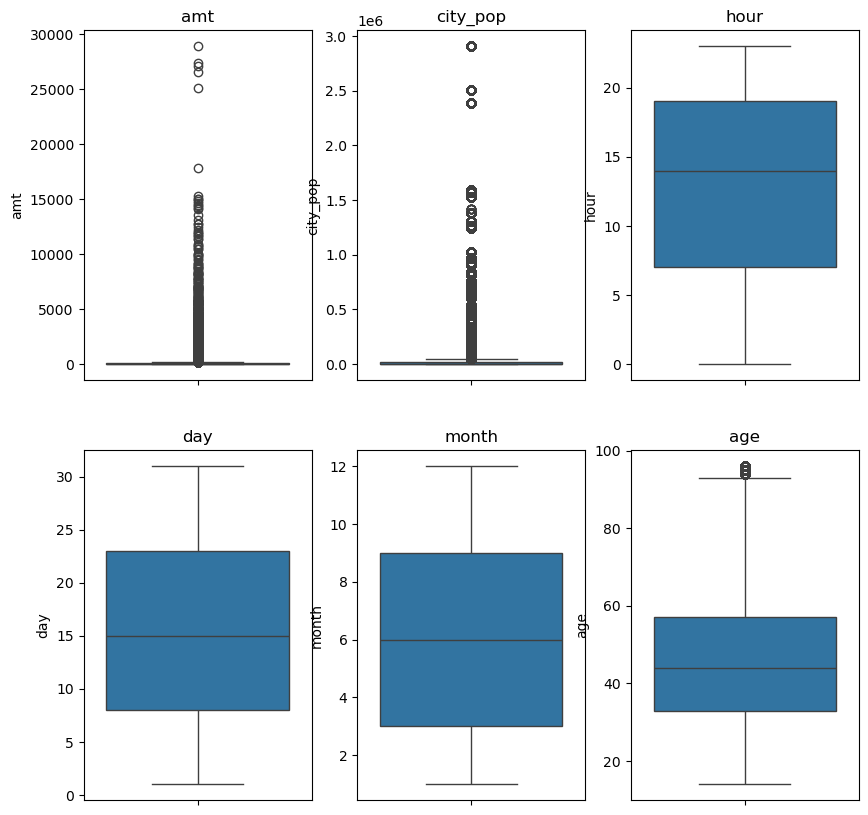

In [24]:
rows_n = 2
fig, axes = plt.subplots(nrows=rows_n, ncols=3 , figsize=(10, 10))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
        sns.boxplot(data=train_df, y=col, ax=axes[i])
        axes[i].set_title(col)

#### That’s **expected** in real-world data and is useful for detecting fraud, so in **fraud detection** we usually do **NOT drop or cap Outliers**

## Exploratory Data Analysis (EDA)

In [25]:
# manually adding annotations to each bar
def annotate_bars(ax):
    for p in ax.patches:
        count = int(p.get_height())
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.text(x, y, str(count), ha='center', va='bottom')

### Label (Target) Distribution

Text(0, 0.5, 'Transaction Count')

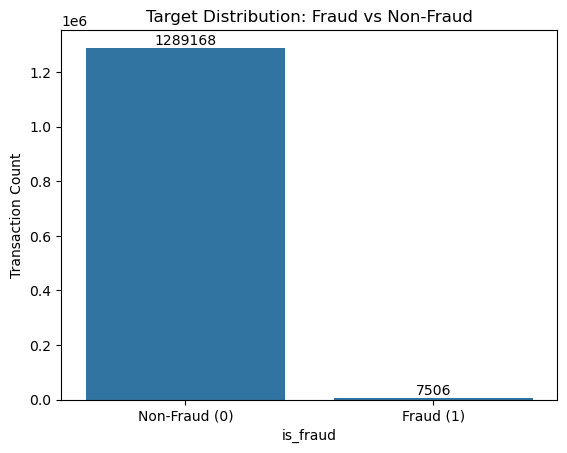

In [26]:
ax = sns.countplot(x='is_fraud', data=train_df)
annotate_bars(ax)
plt.title('Target Distribution: Fraud vs Non-Fraud')
plt.xticks([0, 1], ['Non-Fraud (0)', 'Fraud (1)'])
plt.ylabel('Transaction Count')

#### This figure show that there is **Significan Imbalance** problem in dataset

### Gender Distribution

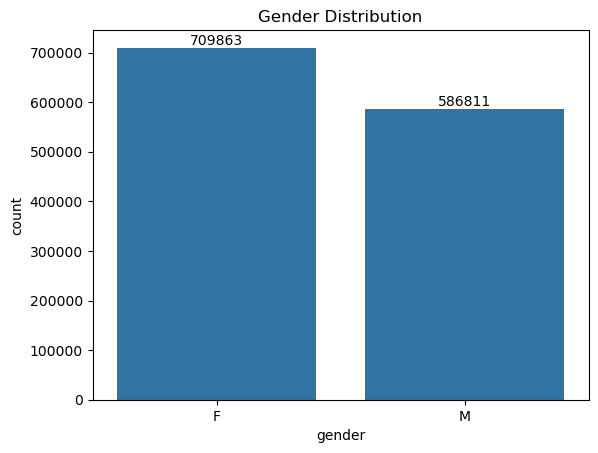

In [27]:
ax = sns.countplot(x='gender', data=train_df)
plt.title('Gender Distribution')
annotate_bars(ax)

#### This figure show that number of **Female** is greater than Male

### Age Distribution

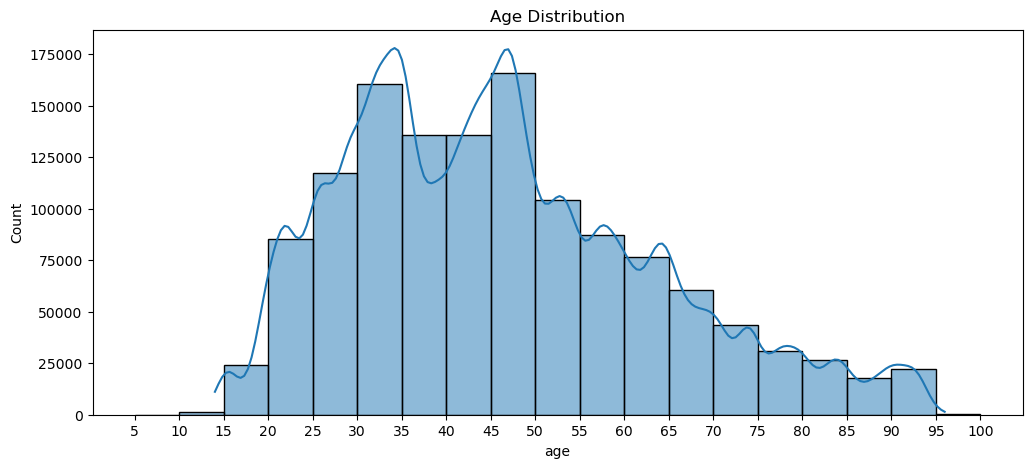

In [28]:
plt.figure(figsize=(12, 5))
sns.histplot(train_df['age'], bins=range(5, 101, 5), kde=True)
plt.title('Age Distribution')
plt.xticks(range(5, 101, 5))
plt.show()

#### This figure show that **most** popular Age of credit owners between [30 : 50]

### Category Distribution

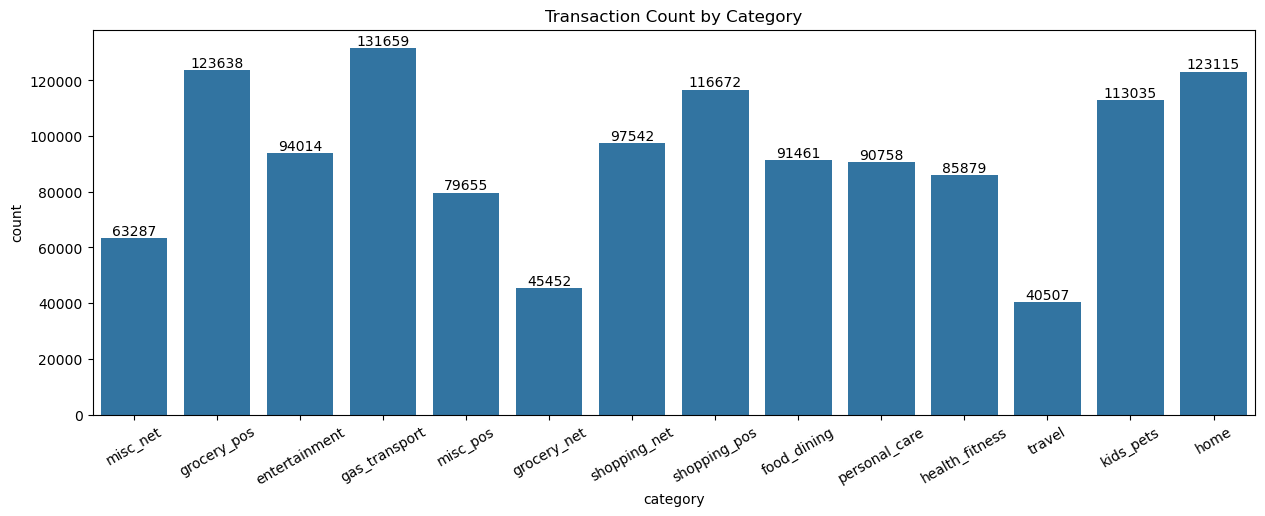

In [29]:
plt.figure(figsize=(15, 5))
ax = sns.countplot(x='category', data=train_df)
plt.title('Transaction Count by Category')
annotate_bars(ax)
plt.xticks(rotation=30)
plt.show()

#### This figure show that **'gas_transport'** is most popular category exist and **'travel'** is the least

### States Distribution (Top 10)

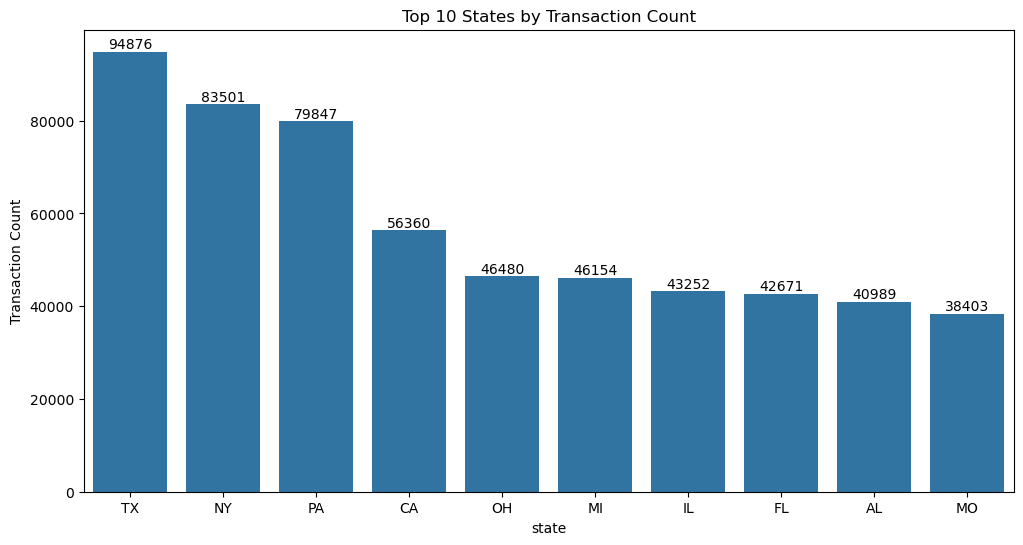

In [30]:
plt.figure(figsize=(12, 6))
top_states = train_df['state'].value_counts().head(10)

ax = sns.barplot(x=top_states.index, y=top_states.values)
plt.title('Top 10 States by Transaction Count')
plt.ylabel('Transaction Count')
annotate_bars(ax)

#### This figure show that **Texas** is the most popular State exist

### Cities Distribution (Top 10)

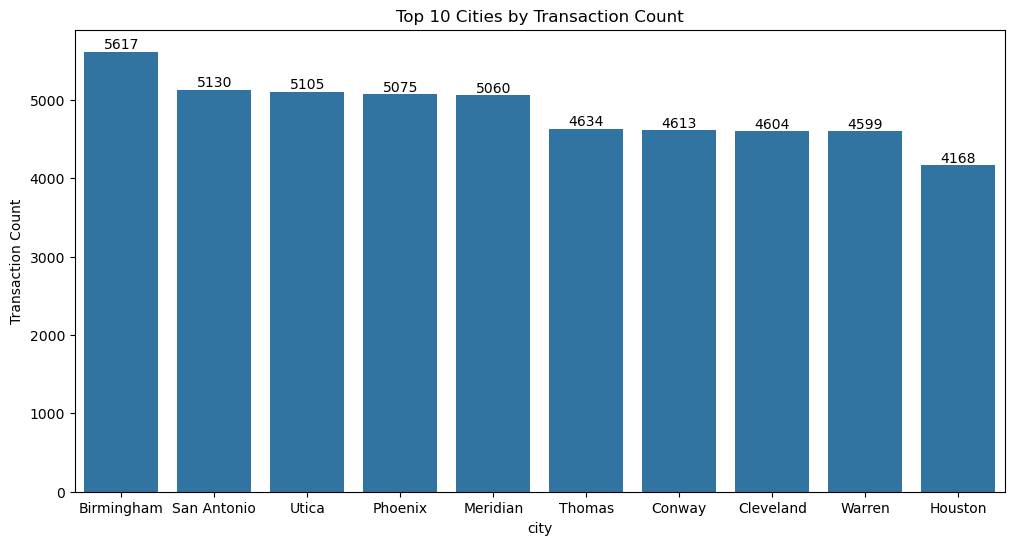

In [31]:
plt.figure(figsize=(12, 6))
top_cities = train_df['city'].value_counts().head(10)

ax = sns.barplot(x=top_cities.index, y=top_cities.values)
plt.title('Top 10 Cities by Transaction Count')
plt.ylabel('Transaction Count')
annotate_bars(ax)

#### This figure show that **Birmingham** is the most popular City exist

### Jobs Distribution (Top 10)

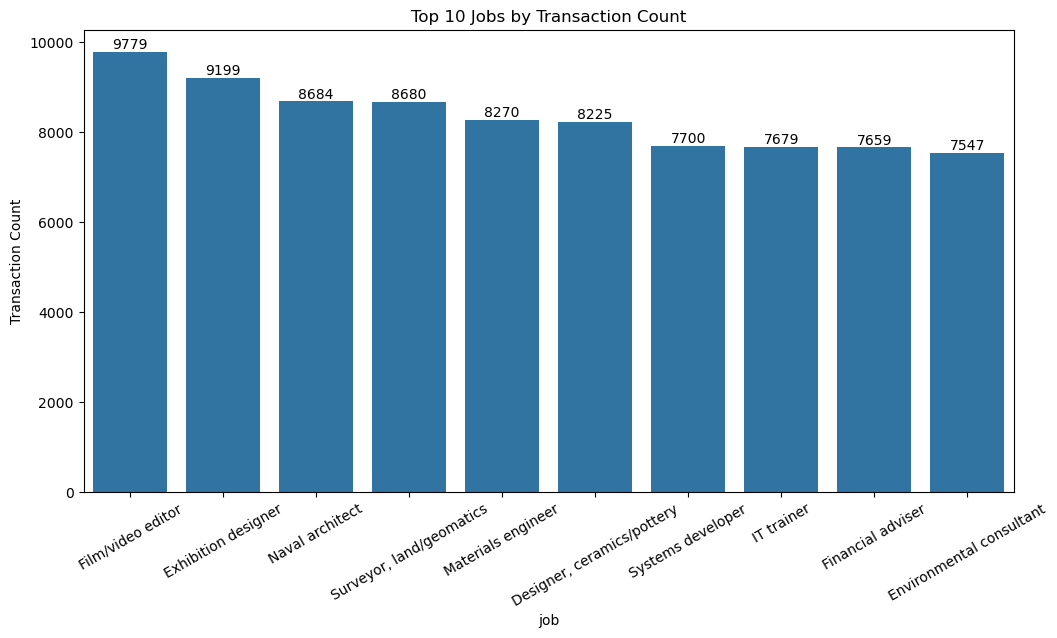

In [32]:
plt.figure(figsize=(12, 6))
top_jobs = train_df['job'].value_counts().head(10)

ax = sns.barplot(x=top_jobs.index, y=top_jobs.values)
plt.title('Top 10 Jobs by Transaction Count')
plt.ylabel('Transaction Count')
annotate_bars(ax)
plt.xticks(rotation=30)
plt.show()

#### This figure show that **Film/video editor** is the most popular Job exist

### Hour of transaction Distribution

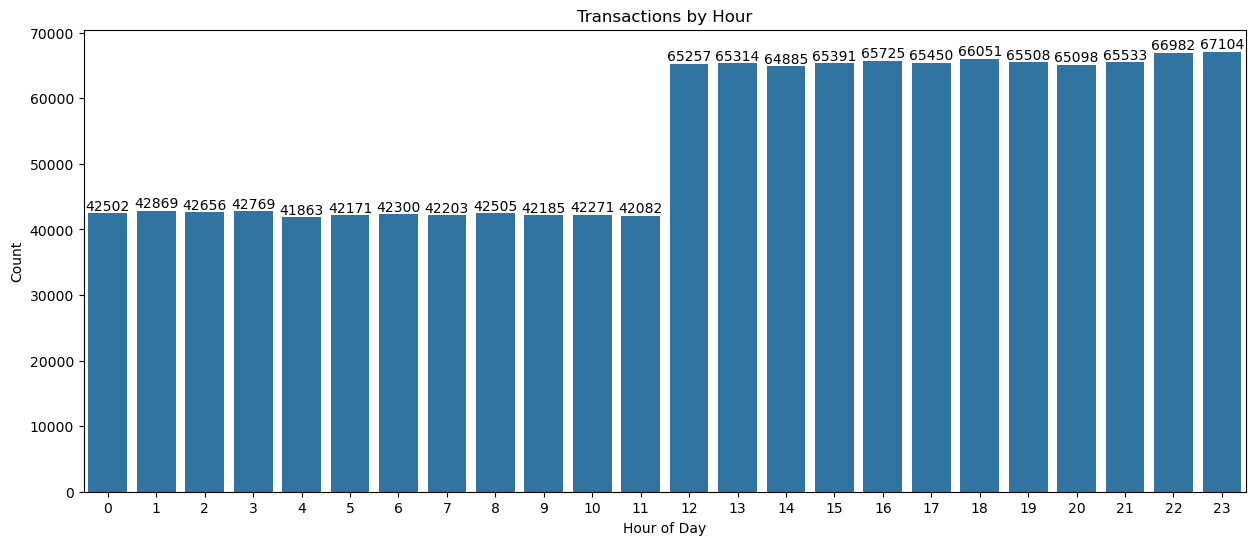

In [33]:
plt.figure(figsize=(15,6))
ax = sns.countplot(x='hour', data=train_df)
plt.title('Transactions by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
annotate_bars(ax)

#### This figure show that most of transaction is done from **12 to 23** o'clock

### Days of transaction Distribution

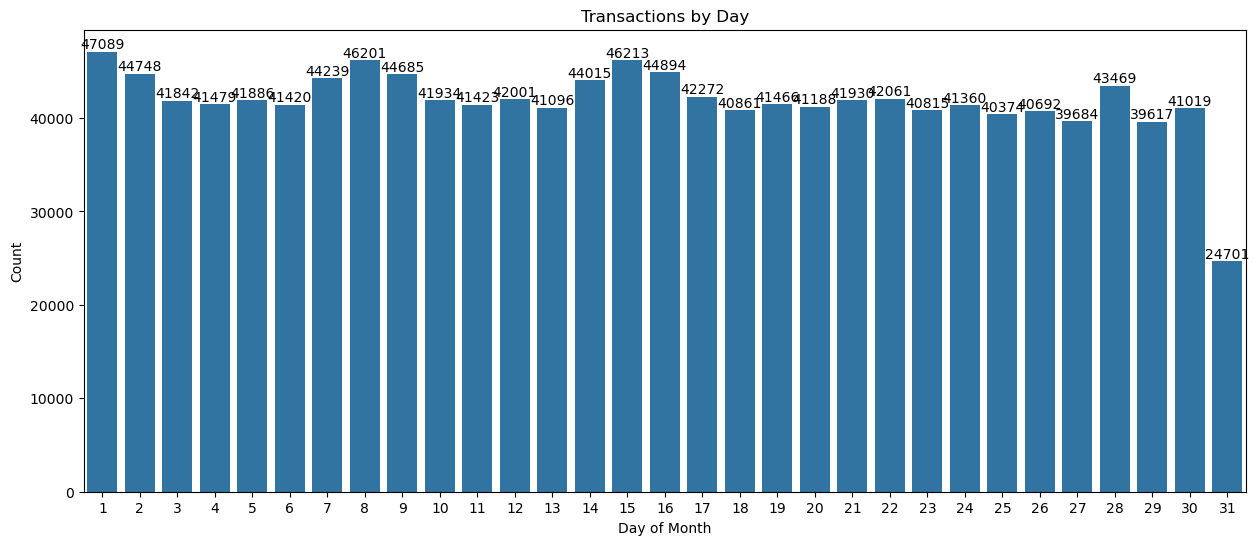

In [34]:
plt.figure(figsize=(15,6))
ax = sns.countplot(x='day', data=train_df)
plt.title('Transactions by Day')
plt.xlabel('Day of Month')
plt.ylabel('Count')
annotate_bars(ax)

#### This figure show that day **31** is the **least** day has transactions

### Month of transaction Distribution

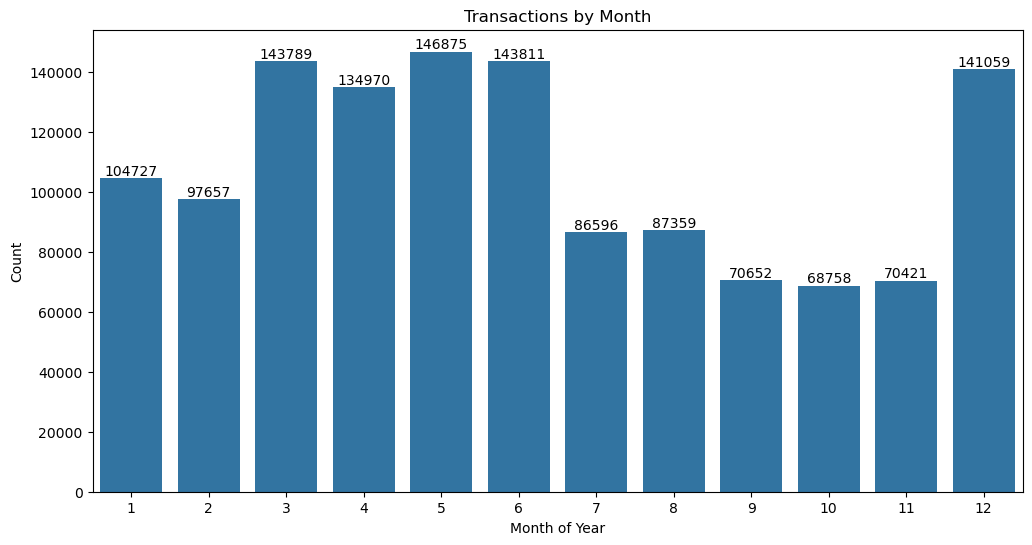

In [35]:
plt.figure(figsize=(12,6))
ax = sns.countplot(x='month', data=train_df)
plt.title('Transactions by Month')
plt.xlabel('Month of Year')
plt.ylabel('Count')
annotate_bars(ax)

#### This figure show that most of transaction is done from **12 & 3:4** Month

### Fraud by Gender

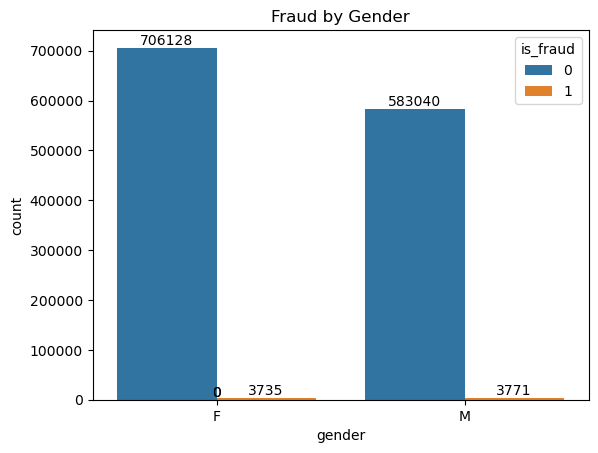

In [36]:
ax = sns.countplot(x='gender', hue='is_fraud', data=train_df)
plt.title('Fraud by Gender')
annotate_bars(ax)

#### This figure show that the Ratio of **Fraud** at **Male** is **greater** than Female

### Fraud by Age

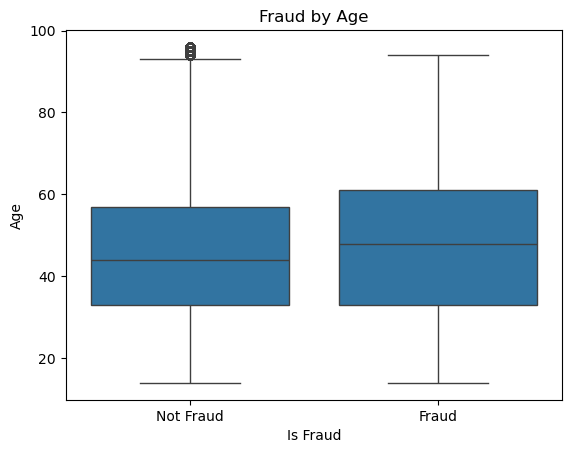

In [37]:
sns.boxplot(x='is_fraud', y='age', data=train_df)
plt.title('Fraud by Age')
plt.xlabel('Is Fraud')
plt.ylabel('Age')
plt.xticks([0, 1], ['Not Fraud', 'Fraud'])
plt.show()

#### This figure show that there is **No Significant Age** that has High Ratio to be Fraud

### Fraud by State (Most 10)

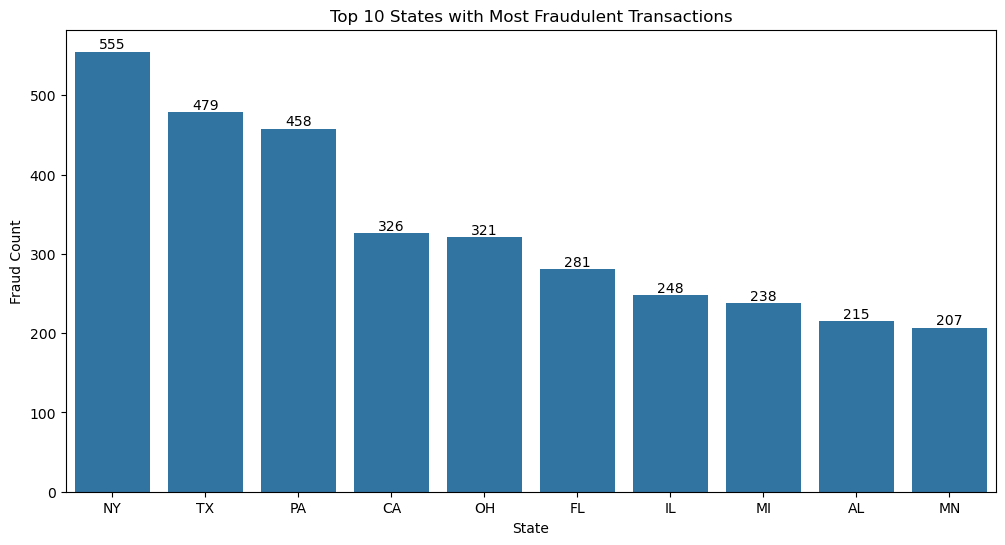

In [38]:
fraud_by_state = train_df[train_df['is_fraud'] == 1].groupby('state').size().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=fraud_by_state.head(10).index, y=fraud_by_state.head(10).values)
plt.title('Top 10 States with Most Fraudulent Transactions')
plt.xlabel('State')
plt.ylabel('Fraud Count')
annotate_bars(ax)

#### This figure show that **New york** is the **most** State has Fraud Transactions

### Fraud by City (Most 10)

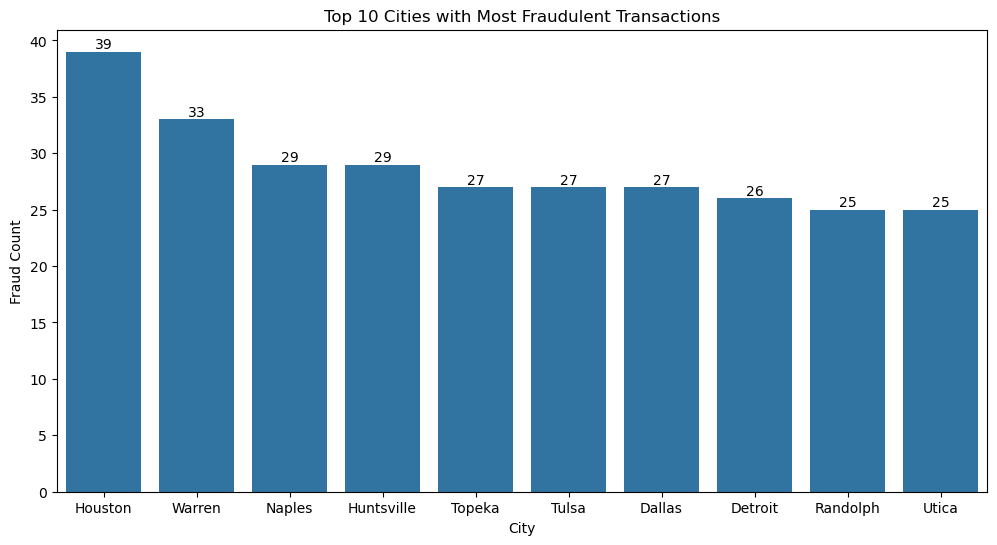

In [39]:
fraud_by_city = train_df[train_df['is_fraud'] == 1].groupby('city').size().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=fraud_by_city.head(10).index, y=fraud_by_city.head(10).values)
plt.title('Top 10 Cities with Most Fraudulent Transactions')
plt.xlabel('City')
plt.ylabel('Fraud Count')
annotate_bars(ax)

#### This figure show that **Houston** is the **most** City has Fraud Transactions

### Fraud by Job (Most 10)

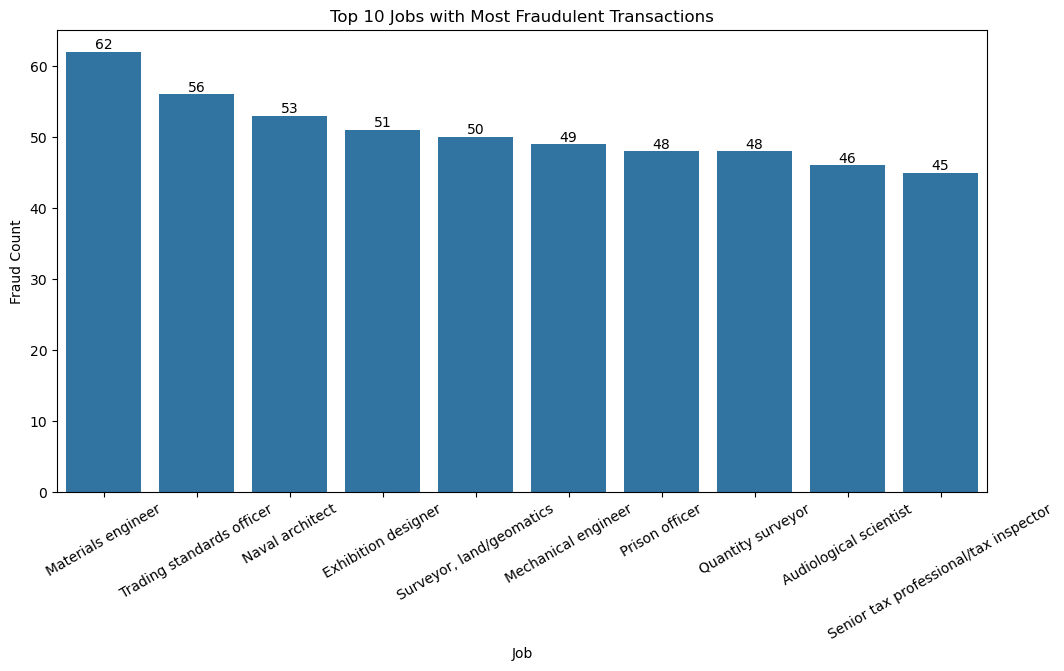

In [40]:
fraud_by_job = train_df[train_df['is_fraud'] == 1].groupby('job').size().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=fraud_by_job.head(10).index, y=fraud_by_job.head(10).values)
plt.title('Top 10 Jobs with Most Fraudulent Transactions')
plt.xlabel('Job')
plt.ylabel('Fraud Count')
annotate_bars(ax)
plt.xticks(rotation=30)
plt.show()

#### This figure show that **Materials engineer** is the **most** Job has Fraud Transactions

### Fraud rate by category

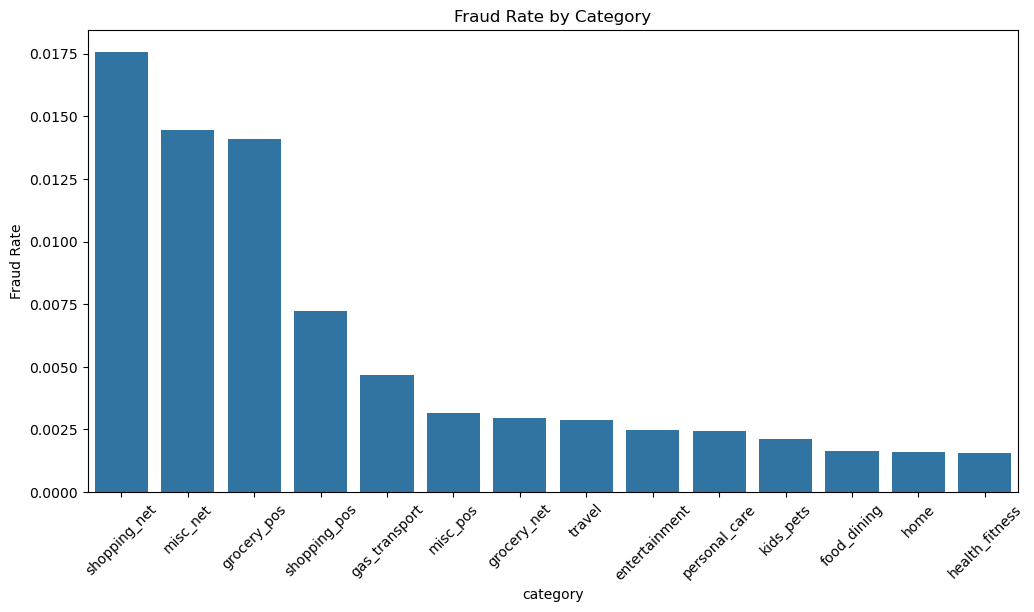

In [41]:
plt.figure(figsize=(12, 6))
fraud_by_cat = train_df.groupby('category')['is_fraud'].mean().sort_values(ascending=False)

ax = sns.barplot(x=fraud_by_cat.index, y=fraud_by_cat.values)
plt.title('Fraud Rate by Category')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45)
plt.show()

#### This figure show that **Fraud Rate** is **incresed** when category is in **[shopping_net , misc_net , grocery_pos]**

### Fraud count by Hour

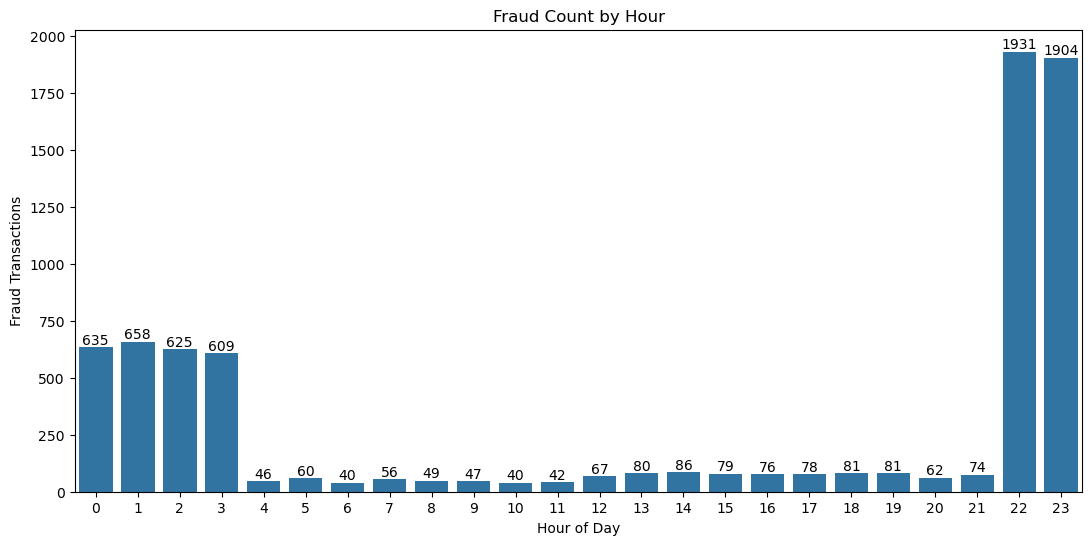

In [42]:
fraud_by_hour = train_df.groupby('hour')['is_fraud'].sum()

plt.figure(figsize=(13, 6))
ax = sns.barplot(x=fraud_by_hour.index, y=fraud_by_hour.values)
plt.title('Fraud Count by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Transactions')
annotate_bars(ax)

#### This figure show that most of **Fraud** is be at **[22 , 23] o'clock and also has big ratio at [0, 1, 2, 3] o'clock

### Fraud count by Day

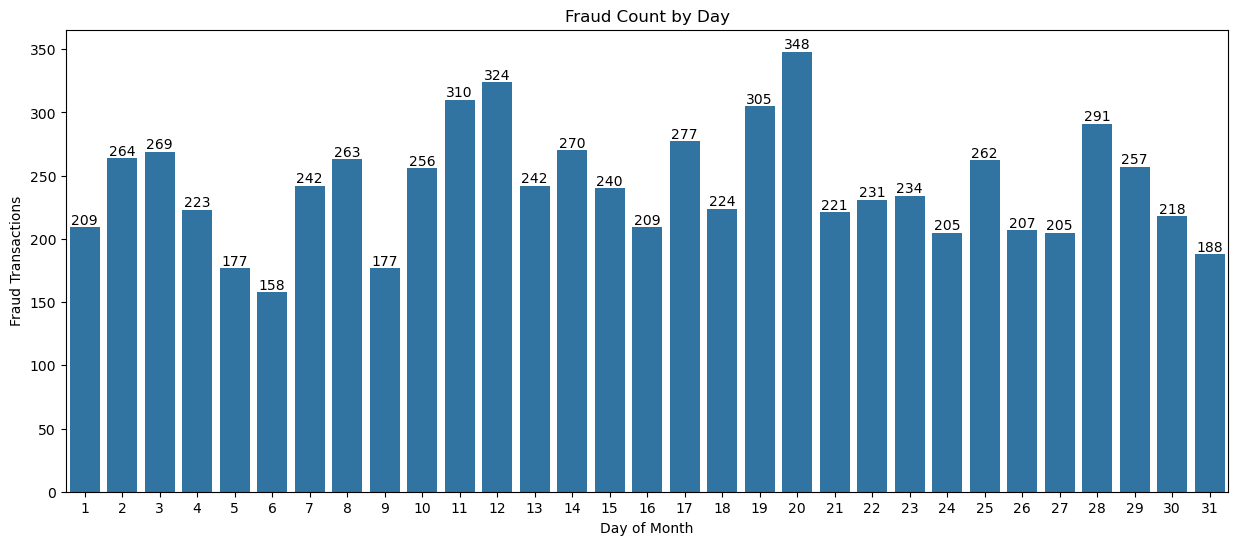

In [43]:
fraud_by_day = train_df.groupby('day')['is_fraud'].sum()

plt.figure(figsize=(15, 6))
ax = sns.barplot(x=fraud_by_day.index, y=fraud_by_day.values)
plt.title('Fraud Count by Day')
plt.xlabel('Day of Month')
plt.ylabel('Fraud Transactions')
annotate_bars(ax)

#### This figure show that most of **Fraud** is be at Day **20** of Month

### Fraud count by Month

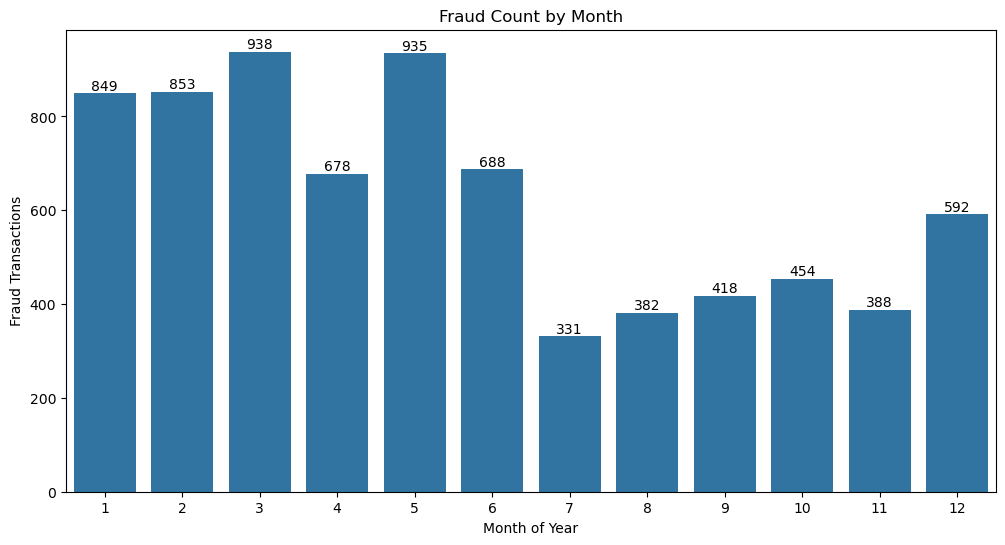

In [44]:
fraud_by_month = train_df.groupby('month')['is_fraud'].sum()

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=fraud_by_month.index, y=fraud_by_month.values)
plt.title('Fraud Count by Month')
plt.xlabel('Month of Year')
plt.ylabel('Fraud Transactions')
annotate_bars(ax)

#### This figure show that most of **Fraud** is be at Months **[3 , 4]** of Year

### Boxplot of amount by fraud label

Text(0, 0.5, 'Transaction Amount ($)')

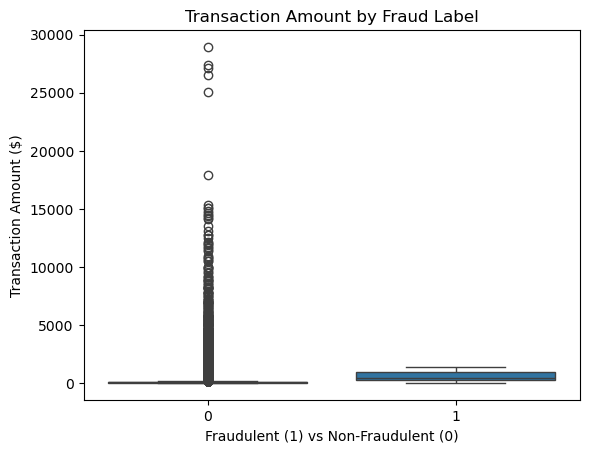

In [45]:
sns.boxplot(x='is_fraud', y='amt', data=train_df)
plt.title('Transaction Amount by Fraud Label')
plt.xlabel('Fraudulent (1) vs Non-Fraudulent (0)')
plt.ylabel('Transaction Amount ($)')

#### This figure show that there is **No-Fraud** at **bigger** transactions (> 5000$)

### Correlation Matrix

Text(0.5, 1.0, 'Correlation Heatmap')

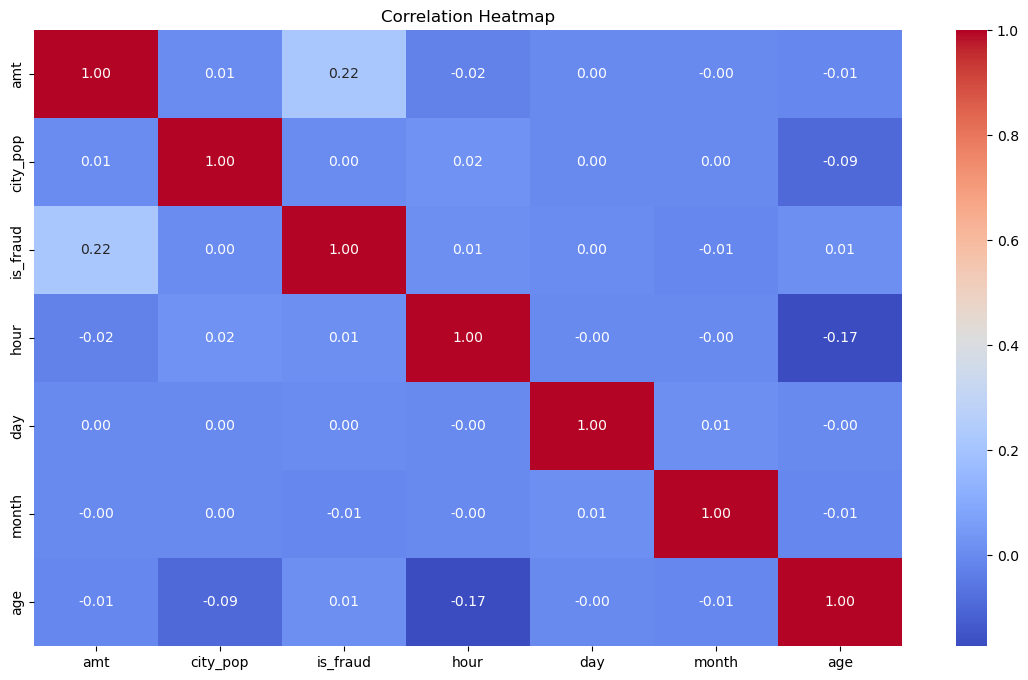

In [46]:
plt.figure(figsize=(14, 8))
corr = train_df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')

## Feature Engineering

### Remove Features not improve Model

In [47]:
train_df.drop(columns=['day', 'month', 'city'], inplace=True)
test_df.drop(columns=['day', 'month', 'city'], inplace=True)

In [48]:
numeric_cols = [col for col in train_df.select_dtypes(include='number').columns if col != 'is_fraud']
categories_cols = train_df.select_dtypes(include='object').columns.tolist()

print("All Features for Modeling:", numeric_cols + categories_cols)

All Features for Modeling: ['amt', 'city_pop', 'hour', 'age', 'merchant', 'category', 'gender', 'state', 'job']


### Splitting

#### Splits the data: 80% Training , 20% Validation

In [49]:
from sklearn.model_selection import train_test_split

In [50]:
X = train_df.drop(columns='is_fraud')
y = train_df['is_fraud']

In [51]:
# 2. Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [52]:
X_test = test_df.drop(columns='is_fraud')
y_test = test_df['is_fraud']

### Encoding

#### Frequency Encoding
bec: High-cardinality categoricals

In [53]:
# Frequency encode high-cardinality categoricals
for col in categories_cols:
    # Create frequency map from train set
    freq_map = X_train[col].value_counts()
    
    # Map to both train and test using this mapping
    X_train[col + '_freq'] = X_train[col].map(freq_map)
    X_val[col + '_freq'] = X_val[col].map(freq_map)
    X_test[col + '_freq'] = X_test[col].map(freq_map)  # Use train freq to avoid leakage

In [54]:
# Drop original categorical columns
X_train.drop(columns=categories_cols, inplace=True)
X_val.drop(columns=categories_cols, inplace=True)
X_test.drop(columns=categories_cols, inplace=True)

### Scalling

#### Use **Robust Scaler** bec: it **less sensitive for Outliers**

In [55]:
from sklearn.preprocessing import RobustScaler

In [56]:
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## Modeling (Logistic Regression)

### Training

In [57]:
from sklearn.linear_model import LogisticRegression

In [58]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

### Evaluation

In [59]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [60]:
y_pred = model.predict(X_val)
y_val.head(), y_pred[:5]

(1161538    0
 192923     0
 1086284    0
 1069483    0
 689806     0
 Name: is_fraud, dtype: int64,
 array([0, 0, 0, 0, 0], dtype=int64))

In [61]:
print("Accuracy:", round(accuracy_score(y_val, y_pred), 2))
print("\nClassification Report:\n", classification_report(y_val, y_pred))

Accuracy: 0.95

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.97    257834
           1       0.08      0.76      0.15      1501

    accuracy                           0.95    259335
   macro avg       0.54      0.86      0.56    259335
weighted avg       0.99      0.95      0.97    259335



## Modeling (SVM)

### Training

In [62]:
from sklearn.svm import LinearSVC

In [63]:
model = LinearSVC(class_weight='balanced')
model.fit(X_train, y_train)

LinearSVC(class_weight='balanced')

### Evaluation

In [64]:
y_pred = model.predict(X_val)
y_val.head(), y_pred[:5]

(1161538    0
 192923     0
 1086284    0
 1069483    0
 689806     0
 Name: is_fraud, dtype: int64,
 array([0, 0, 0, 0, 0], dtype=int64))

In [65]:
print("Accuracy:", round(accuracy_score(y_val, y_pred), 2))
print("\nClassification Report:\n", classification_report(y_val, y_pred))

Accuracy: 0.97

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98    257834
           1       0.12      0.75      0.21      1501

    accuracy                           0.97    259335
   macro avg       0.56      0.86      0.59    259335
weighted avg       0.99      0.97      0.98    259335



## Modeling (KNN)

### Training

In [66]:
from sklearn.neighbors import KNeighborsClassifier

In [67]:
model = KNeighborsClassifier()
model.fit(X_train, y_train)

KNeighborsClassifier()

### Evaluation

In [68]:
y_pred = model.predict(X_val)
y_val.head(), y_pred[:5]

(1161538    0
 192923     0
 1086284    0
 1069483    0
 689806     0
 Name: is_fraud, dtype: int64,
 array([0, 0, 0, 0, 0], dtype=int64))

In [69]:
print("Accuracy:", round(accuracy_score(y_val, y_pred), 2))
print("\nClassification Report:\n", classification_report(y_val, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.86      0.60      0.71      1501

    accuracy                           1.00    259335
   macro avg       0.93      0.80      0.85    259335
weighted avg       1.00      1.00      1.00    259335



## Modeling (Random Forest)

### Training

In [70]:
from sklearn.ensemble import RandomForestClassifier

In [71]:
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

### Evaluation

In [72]:
y_pred = model.predict(X_val)
y_val.head(), y_pred[:5]

(1161538    0
 192923     0
 1086284    0
 1069483    0
 689806     0
 Name: is_fraud, dtype: int64,
 array([0, 0, 0, 0, 0], dtype=int64))

In [73]:
print("Accuracy:", round(accuracy_score(y_val, y_pred), 2))
print("\nClassification Report:\n", classification_report(y_val, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.97      0.80      0.88      1501

    accuracy                           1.00    259335
   macro avg       0.98      0.90      0.94    259335
weighted avg       1.00      1.00      1.00    259335



In [74]:
y_pred_t = model.predict(X_test)
y_test.head(), y_pred_t[:5]

(0    0
 1    0
 2    0
 3    0
 4    0
 Name: is_fraud, dtype: int64,
 array([0, 0, 0, 0, 0], dtype=int64))

In [75]:
print("Accuracy:", round(accuracy_score(y_test, y_pred_t), 2))
print("\nClassification Report:\n", classification_report(y_test, y_pred_t))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.95      0.76      0.85      2145

    accuracy                           1.00    555719
   macro avg       0.97      0.88      0.92    555719
weighted avg       1.00      1.00      1.00    555719



## Full Pipeline

### Import Required Libraries

In [76]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

### Create Classes for Required Preprocessing Process

In [77]:
# Custom Transformers
class DatetimeTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, time_col='trans_date_trans_time', dob_col='dob'):
        self.time_col = time_col
        self.dob_col = dob_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.time_col] = pd.to_datetime(X[self.time_col])
        X[self.dob_col] = pd.to_datetime(X[self.dob_col])
        X['hour'] = X[self.time_col].dt.hour
        X['age'] = X[self.time_col].dt.year - X[self.dob_col].dt.year
        return X.drop(columns=[self.time_col, self.dob_col])


class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
        self.freq_maps = {}

    def fit(self, X, y=None):
        for col in self.columns:
            self.freq_maps[col] = X[col].value_counts()
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            X[col + '_freq'] = X[col].map(self.freq_maps[col]).fillna(0)
        return X.drop(columns=self.columns)


# Drop Unused Columns
class ColumnDropper(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_drop):
        self.columns_to_drop = columns_to_drop

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=self.columns_to_drop)

### Pipeline Definition

In [78]:
numeric_cols = ['amt', 'city_pop']
categorical_cols = ['category', 'gender', 'state', 'job', 'merchant']
drop_cols = ['cc_num', 'first', 'last', 'street', 'zip', 
             'trans_num', 'unix_time', 'lat', 'long', 'merch_lat', 'merch_long', 'city']

data_cleaning_pipeline = Pipeline([
    ('drop_cols', ColumnDropper(columns_to_drop=drop_cols)),
    ('datetime_features', DatetimeTransformer(time_col='trans_date_trans_time', dob_col='dob')),
    ('freq_encoding', FrequencyEncoder(columns=categorical_cols)),
    ('scaling', RobustScaler())
])

full_pipeline = Pipeline([
    ('preprocessing', data_cleaning_pipeline),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

### Data Preparation

In [79]:
train_df = pd.read_csv('fraudTrain.csv')
test_df = pd.read_csv('fraudTest.csv')

train_df.drop(columns='Unnamed: 0', inplace=True)
test_df.drop(columns='Unnamed: 0', inplace=True)

X_train = train_df.drop(columns='is_fraud')
y_train = train_df['is_fraud']

X_test = test_df.drop(columns='is_fraud')
y_test = test_df['is_fraud']

### Pipeline Training

In [80]:
full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('drop_cols',
                                  ColumnDropper(columns_to_drop=['cc_num',
                                                                 'first',
                                                                 'last',
                                                                 'street',
                                                                 'zip',
                                                                 'trans_num',
                                                                 'unix_time',
                                                                 'lat', 'long',
                                                                 'merch_lat',
                                                                 'merch_long',
                                                                 'city'])),
                                 ('datetime_features', DatetimeTransformer()),
                                 ('freq_encoding',
                                  FrequencyEncoder(columns=['category',
                                                            'gender', 'state',
                                                            'job',
                                                            'merchant'])),
                                 ('scaling', RobustScaler())])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

### Pipeline Evaluation

In [81]:
y_pred = full_pipeline.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 2))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.95      0.77      0.85      2145

    accuracy                           1.00    555719
   macro avg       0.97      0.89      0.93    555719
weighted avg       1.00      1.00      1.00    555719



#### Confusion Matrix

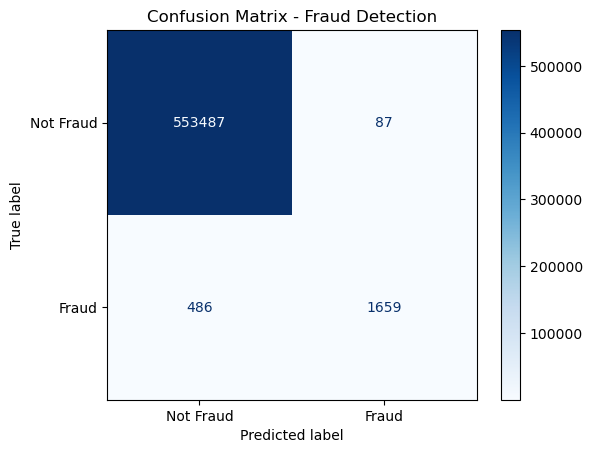

In [82]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred),
                               display_labels=["Not Fraud", "Fraud"])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix - Fraud Detection")
plt.show()

### Pipeline Saving

In [83]:
import joblib

joblib.dump(full_pipeline, 'credit_fraud_detection_pipeline.pkl')

['credit_fraud_detection_pipeline.pkl']

### Prediction

In [84]:
# Predict Example
sample = pd.DataFrame([{
    'amt': 107.23,
    'city_pop': 149,
    'trans_date_trans_time': '2019-01-01 00:00:00',
    'dob': '1978-06-21',
    'category': 'grocery_pos',
    'gender': 'F',
    'city': 'Orient',
    'state': 'WA',
    'job': 'Special educational needs teacher',
    'merchant': 'fraud_Heller, Gutmann and Zieme',
    'cc_num': '630423000000000',
    'first': 'Stephanie',
    'last': 'Gill',
    'street': '43039 Riley Greens Suite 393',
    'zip': 99160,
    'trans_num': 'dummy_txn_id',
    'unix_time': 1325376044,
    'lat': 48.8878,
    'long': -118.2105,
    'merch_lat': 49.159047,
    'merch_long': -118.186462
}])

In [85]:
# Load pipeline
loaded_pipeline = joblib.load('credit_fraud_detection_pipeline.pkl')

# Use it for prediction
prediction = loaded_pipeline.predict(sample)
print("Prediction:", "Fraud" if prediction[0] == 1 else "Not Fraud")

Prediction: Not Fraud
